In [9]:
##### SI Figure 7: 10th and 90th percentile predictions of intensities

from pathlib import Path
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib import cm

In [4]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

# central pixel estimates
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# percentile pixel estimates
capital_intensity_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne_p10.tif")
capital_intensity_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne_p90.tif")
labor_intensity_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne_p10.tif")
labor_intensity_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne_p90.tif")

# country boundaries (used only to mark no-data countries, as in the original script)
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
has_data = pd.read_csv(f"{cd}/Data/Correspondence_tables/has_data.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [5]:
### Data prep

target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

# reproject the central rasters, then match every other raster to that grid so
# all six layers line up pixel-for-pixel
capital_intensity = capital_intensity.rio.reproject(target_crs)
labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)

capital_intensity_p10 = capital_intensity_p10.rio.reproject_match(capital_intensity)
capital_intensity_p90 = capital_intensity_p90.rio.reproject_match(capital_intensity)
labor_intensity_p10 = labor_intensity_p10.rio.reproject_match(capital_intensity)
labor_intensity_p90 = labor_intensity_p90.rio.reproject_match(capital_intensity)

country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)

country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

# identify no-data countries (same logic as original script)

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

# compute % difference between percentile and central estimates

def pct_diff(percentile_raster, central_raster):
    """(percentile - central) / central * 100, with divide-by-zero/negative-value
    protection — cells where the central estimate is <= 0 are set to NaN."""
    central = central_raster.squeeze()
    percentile = percentile_raster.squeeze()

    safe_central = xr.where(central > 0, central, np.nan)
    diff = (percentile - central) / safe_central * 100
    return diff

capital_pct_p10 = pct_diff(capital_intensity_p10, capital_intensity)
capital_pct_p90 = pct_diff(capital_intensity_p90, capital_intensity)
labor_pct_p10 = pct_diff(labor_intensity_p10, labor_intensity)
labor_pct_p90 = pct_diff(labor_intensity_p90, labor_intensity)

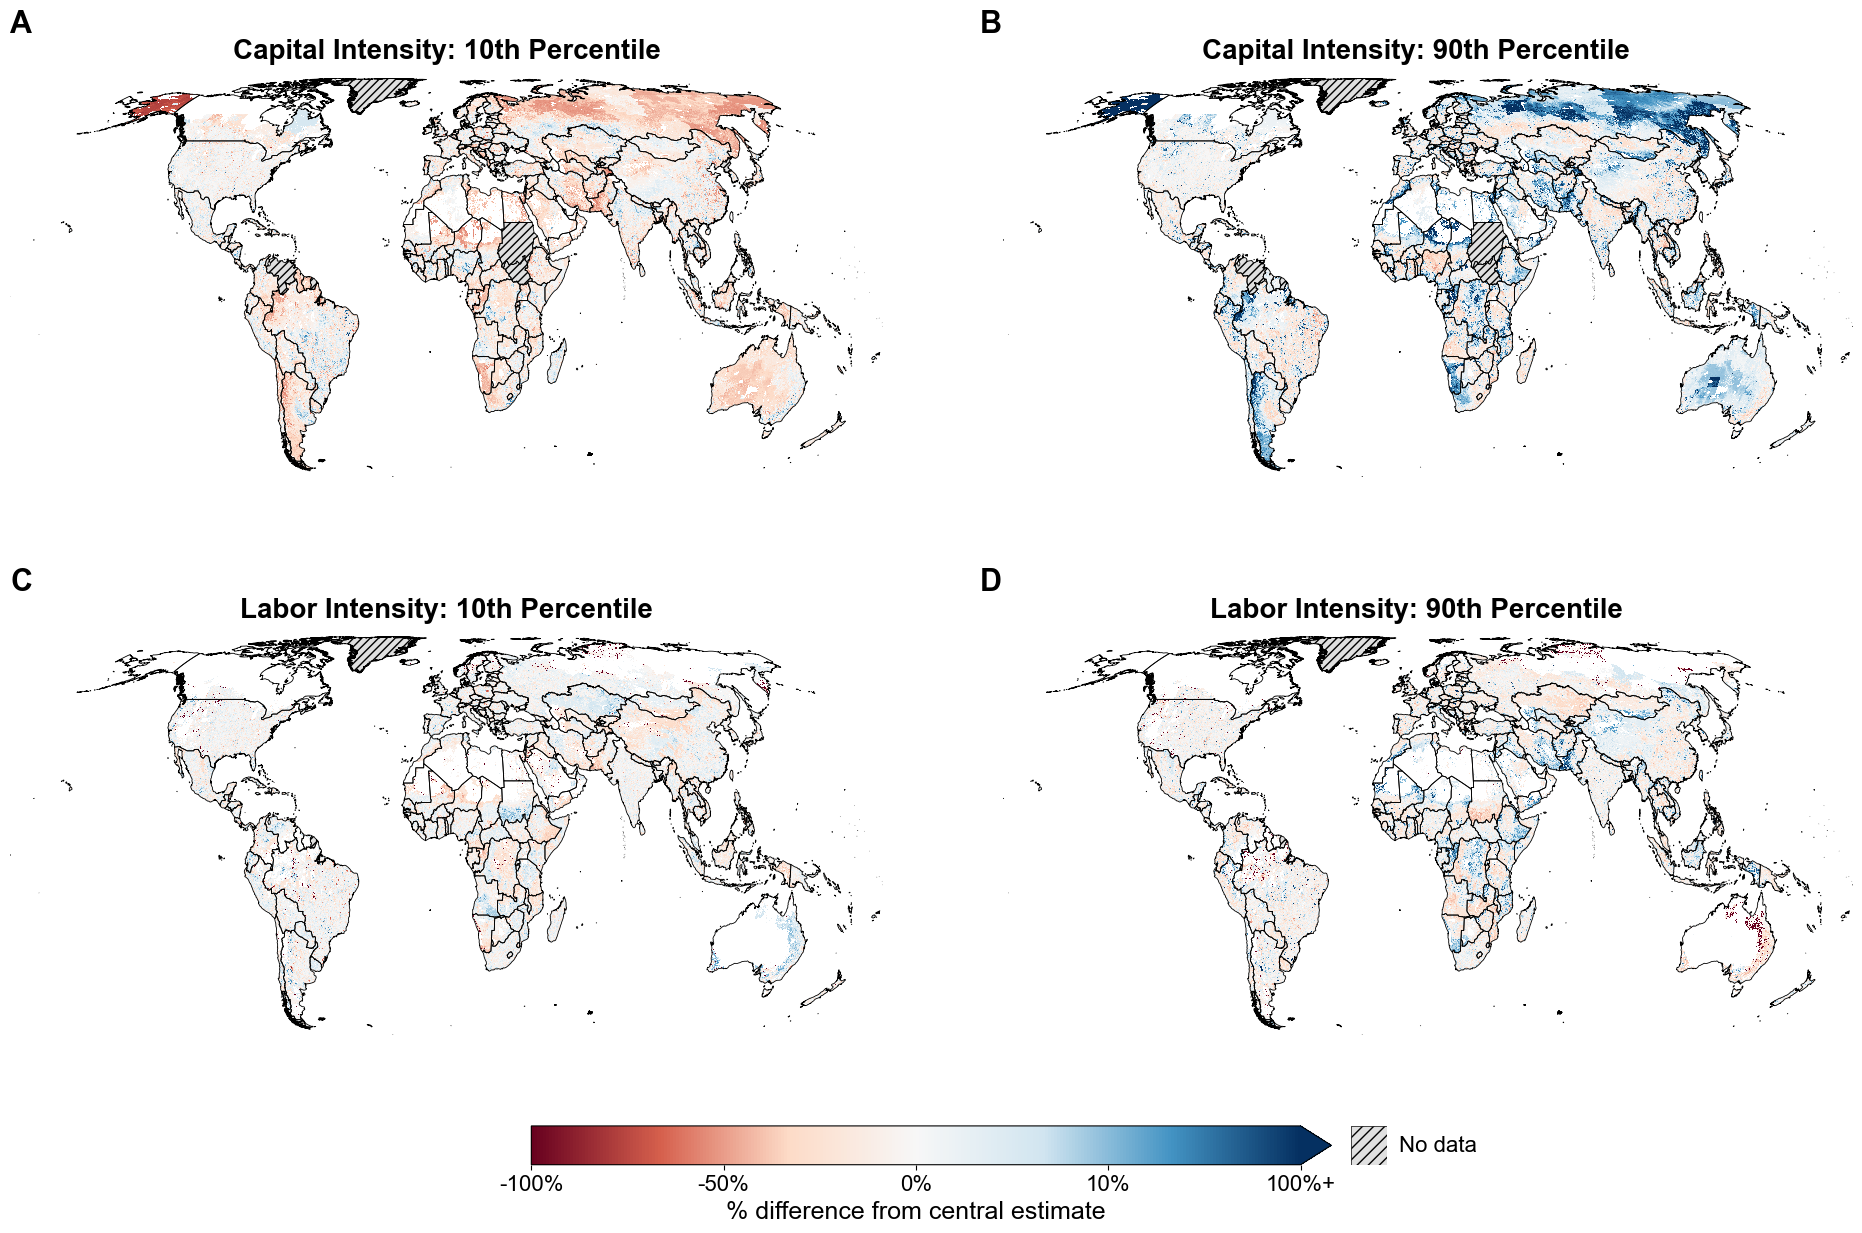

In [11]:
#### Map uncertainty side-by-side

# Enforce Arial/Helvetica sans-serif for all text in the figure
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]


def plot_uncertainty_grid(specs, country_gdf, out_path, missing_color="#e0e0e0"):
    """specs: 2x2 nested list of dicts, one per panel, in row-major order:
    [[top_left, top_right], [bottom_left, bottom_right]]
    each dict needs: raster (pct-diff DataArray), coverage_col, title
    """
    minx, miny, maxx, maxy = country_gdf.total_bounds
    data_w = maxx - minx
    data_h = maxy - miny

    fig_width = 20
    panel_width = fig_width / 2
    map_height = panel_width * (data_h / data_w)
    row_height = map_height + 1.4
    fig_height = row_height * 2 + 1.0

    fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height))

    # -100% is a hard floor (can't be more than 100% below the central estimate),
    # so the colorbar is only open-ended on the high side
    bounds = [-100, -50, 0, 50, 100]
    labels = ['-100%', '-50%', '0%', '10%', '100%+']

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "uncertainty_diverging",
        ["#67001f", "#d6604d", "#fddbc7", "#f7f7f7", "#d1e5f0", "#4393c3", "#053061"]
    )
    cmap.set_over("#053061")

    positions = np.linspace(0, 1, len(bounds))

    def forward(x):
        return np.interp(x, bounds, positions)

    def inverse(x):
        return np.interp(x, positions, bounds)

    norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

    panel_letters = [["A", "B"], ["C", "D"]]

    im = None
    for row_idx in range(2):
        for col_idx in range(2):
            spec = specs[row_idx][col_idx]
            ax = axes[row_idx, col_idx]
            raster = spec["raster"]
            coverage_col = spec["coverage_col"]
            title = spec["title"]

            country_gdf[country_gdf[coverage_col] == 0].plot(
                ax=ax, facecolor=missing_color, edgecolor="none", hatch="////", zorder=1
            )

            im = raster.plot(
                ax=ax, cmap=cmap, norm=norm,
                add_colorbar=False, add_labels=False, zorder=2
            )

            country_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

            ax.set_xlim(minx, maxx)
            ax.set_ylim(miny, maxy)
            ax.set_aspect("equal")
            ax.set_axis_off()

            ax.set_title(title, fontsize=20, weight="bold", pad=14, fontfamily="sans-serif")

            ax.text(
                0.0, 1.10, panel_letters[row_idx][col_idx],
                transform=ax.transAxes,
                fontsize=22, fontweight="bold",
                fontfamily="sans-serif",
                va="bottom", ha="left"
            )

    fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.16, hspace=0.4, wspace=0.02)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.30, 0.06, 0.4, 0.03])
    cbar = fig.colorbar(
        sm, cax=cbar_ax, orientation="horizontal",
        extend='max', extendfrac=0.04,
    )
    cbar.set_label("% difference from central estimate", fontsize=18, fontfamily="sans-serif")
    cbar.ax.tick_params(labelsize=16)
    for tick_label in cbar.ax.get_xticklabels():
        tick_label.set_fontfamily("sans-serif")
    cbar.set_ticks(bounds)
    cbar.set_ticklabels(labels)

    fig.canvas.draw()
    cbar_pos = cbar.ax.get_position()

    swatch_size = 0.018
    gap = 0.025

    legend_ax = fig.add_axes([
        cbar_pos.x1 + gap,
        cbar_pos.y0,
        swatch_size,
        cbar_pos.height
    ])
    legend_ax.add_patch(mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=missing_color,
        edgecolor="black",
        linewidth=0.5,
        hatch="///"
    ))
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.set_xticks([])
    legend_ax.set_yticks([])
    legend_ax.axis("off")

    fig.text(
        cbar_pos.x1 + gap + swatch_size + 0.006,
        cbar_pos.y0 + cbar_pos.height / 2,
        "No data",
        fontsize=16, va="center", ha="left", fontfamily="sans-serif"
    )

    fig.savefig(
        out_path, dpi=300, bbox_inches="tight", pad_inches=0.1,
        pil_kwargs={"compression": "tiff_lzw"}
    )
    plt.show()


specs = [
    [
        dict(raster=capital_pct_p10, coverage_col="has_capital_data", title="Capital Intensity: 10th Percentile"),
        dict(raster=capital_pct_p90, coverage_col="has_capital_data", title="Capital Intensity: 90th Percentile"),
    ],
    [
        dict(raster=labor_pct_p10, coverage_col="has_labor_data", title="Labor Intensity: 10th Percentile"),
        dict(raster=labor_pct_p90, coverage_col="has_labor_data", title="Labor Intensity: 90th Percentile"),
    ],
]

plot_uncertainty_grid(
    specs, country_boundaries,
    out_path=f"{fd}/SI_fig_7_intensity_uncertainty.tiff"
)